In [ ]:
!pip install -q torch torchvision torchaudio transformers pillow matplotlib

In [63]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from xgboost import XGBClassifier

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Load model

In [ ]:
model_name = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

model.eval()
print("Model loaded on", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Model loaded on cuda


# Helper functions

In [ ]:
def load_image_from_url(url: str) -> Image.Image:
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")

def show_images(images, titles=None, cols=4, figsize=(12, 6)):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        if titles is not None:
            plt.title(titles[i], fontsize=8)
    plt.tight_layout()
    plt.show()

def get_image_embeddings(images):
    """
    images: list of PIL images
    returns: tensor [num_images, dim]
    """
    inputs = processor(
        images=images,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model.get_image_features(**inputs)

    # L2-normalize
    embeddings = outputs / outputs.norm(dim=-1, keepdim=True)
    return embeddings

def get_text_embeddings(texts):
    """
    texts: list of strings
    returns: tensor [num_texts, dim]
    """
    inputs = processor(
        text=texts,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model.get_text_features(**inputs)

    # L2-normalize
    embeddings = outputs / outputs.norm(dim=-1, keepdim=True)
    return embeddings

def cosine_similarity_matrix(a, b):
    """
    a: [N, D], b: [M, D]
    returns: [N, M] cosine similarities
    """
    return a @ b.T


# Example Images

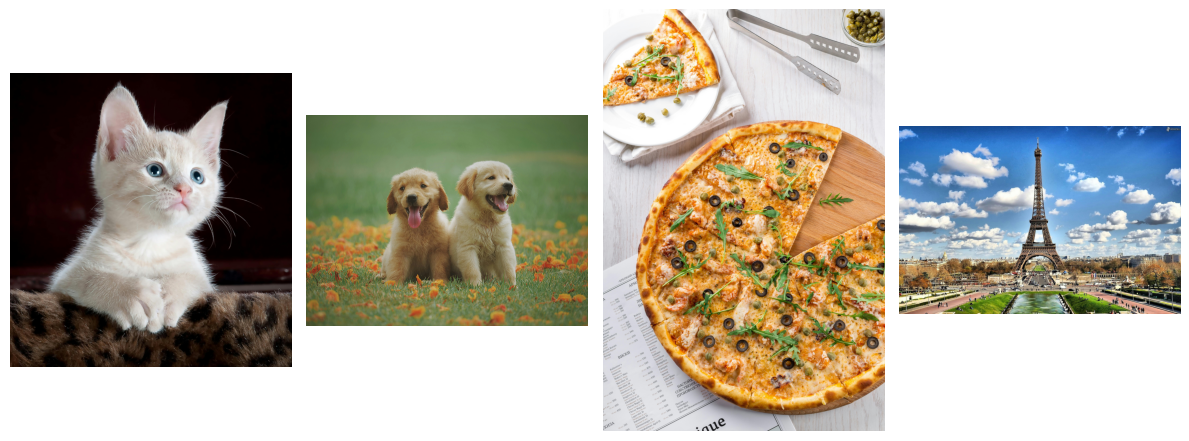

In [ ]:
image_urls = [
    "https://images.pexels.com/photos/45201/kitty-cat-kitten-pet-45201.jpeg",  # cat
    "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg",      # dog
    "https://images.pexels.com/photos/315755/pexels-photo-315755.jpeg",        # pizza
    "https://images.pexels.com/photos/338515/pexels-photo-338515.jpeg",        # city
]

images = [load_image_from_url(url) for url in image_urls]
show_images(images)

In [ ]:
# Some captions (deliberately right and wrong)
captions = [
    "a cute cat lying on the floor",
    "a dog running on the grass",
    "a delicious pizza with cheese",
    "a big city skyline at night",
    "a small boat on the lake",
    "a person riding a bicycle"
]

image_embeds = get_image_embeddings(images)   # [num_images, dim]
text_embeds = get_text_embeddings(captions)   # [num_captions, dim]

# text x image similarity
sim_matrix = cosine_similarity_matrix(text_embeds, image_embeds)  # [T, I]

In [ ]:
import pandas as pd

df = pd.DataFrame(
    sim_matrix.cpu().numpy(),
    index=[f"text_{i}" for i in range(len(captions))],
    columns=[f"img_{i}" for i in range(len(images))]
)
df.style.background_gradient(axis=None)

,img_0,img_1,img_2,img_3
text_0,0.251572,0.167825,0.133538,0.156284
text_1,0.159380,0.256131,0.094724,0.173322
text_2,0.187667,0.188873,0.272144,0.169801
text_3,0.156490,0.134233,0.104733,0.181715
text_4,0.165429,0.152292,0.134905,0.180943
text_5,0.166639,0.153589,0.130487,0.199418


In [ ]:
for img_idx in range(len(images)):
    sims_for_image = sim_matrix[:, img_idx]
    best_idx = torch.argmax(sims_for_image).item()
    print(f"Image {img_idx} best caption:")
    print(f"  -> \"{captions[best_idx]}\" (score={sims_for_image[best_idx]:.3f})")


Image 0 best caption:
  -> "a cute cat lying on the floor" (score=0.252)
Image 1 best caption:
  -> "a dog running on the grass" (score=0.256)
Image 2 best caption:
  -> "a delicious pizza with cheese" (score=0.272)
Image 3 best caption:
  -> "a person riding a bicycle" (score=0.199)


# Tiny Image-Text Search Engine

In [ ]:
image_embeds = get_image_embeddings(images)

In [ ]:
def search_images(query, images, image_embeds, top_k=3):
    """
    query: text string
    images: list of PIL images
    image_embeds: [num_images, dim] tensor
    """
    text_embed = get_text_embeddings([query])  # [1, dim]
    sims = cosine_similarity_matrix(text_embed, image_embeds)  # [1, num_images]
    sims = sims.squeeze(0)  # [num_images]

    # Sort by similarity
    top_scores, top_indices = torch.topk(sims, k=top_k)
    top_indices = top_indices.cpu().tolist()
    top_scores = top_scores.cpu().tolist()

    print(f"Query: \"{query}\"")
    for rank, (idx, score) in enumerate(zip(top_indices, top_scores), start=1):
        print(f"Rank {rank}: image {idx}, score={score:.3f}")

    # Show images
    top_images = [images[i] for i in top_indices]
    titles = [f"rank {r}\nscore={s:.3f}" for r, s in enumerate(top_scores, start=1)]
    show_images(top_images, titles=titles, cols=top_k, figsize=(4 * top_k, 4))

    return top_indices, top_scores

Query: "a cute cat"
Rank 1: image 0, score=0.286
Rank 2: image 1, score=0.195
Rank 3: image 3, score=0.179


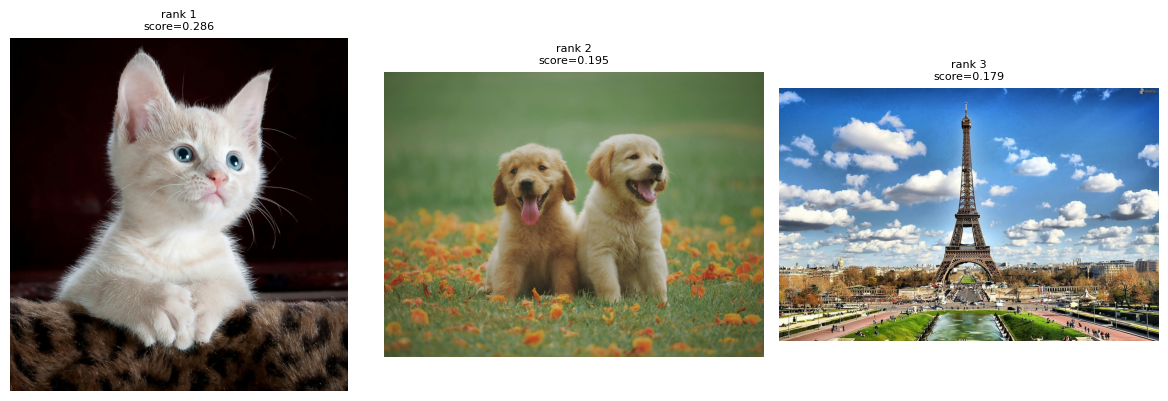

([0, 1, 3], [0.28641870617866516, 0.19501051306724548, 0.17924381792545319])

In [ ]:
search_images("a cute cat", images, image_embeds, top_k=3)

Query: "a city at night"
Rank 1: image 3, score=0.185
Rank 2: image 0, score=0.160
Rank 3: image 1, score=0.129


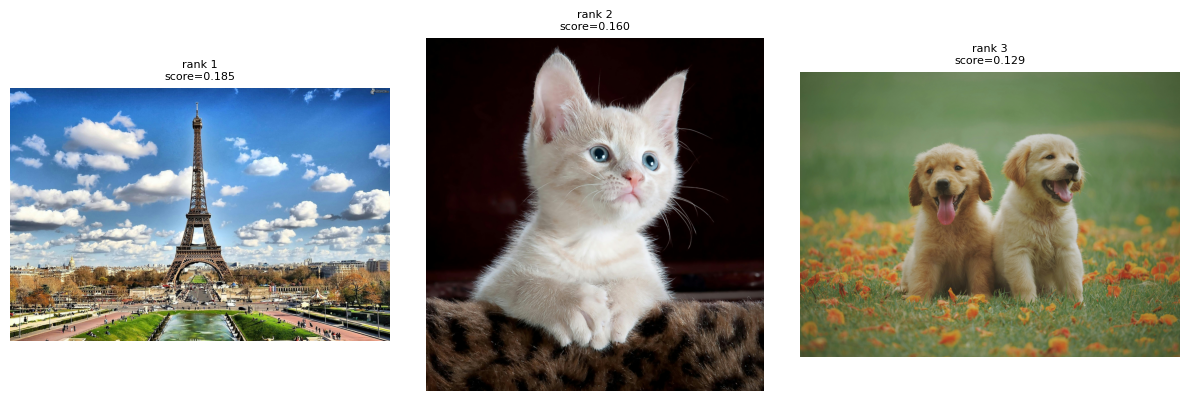

([3, 0, 1], [0.1854878067970276, 0.1596922129392624, 0.12903915345668793])

In [ ]:
search_images("a city at night", images, image_embeds, top_k=3)

Query: "tasty food with cheese"
Rank 1: image 2, score=0.250
Rank 2: image 1, score=0.220
Rank 3: image 0, score=0.202


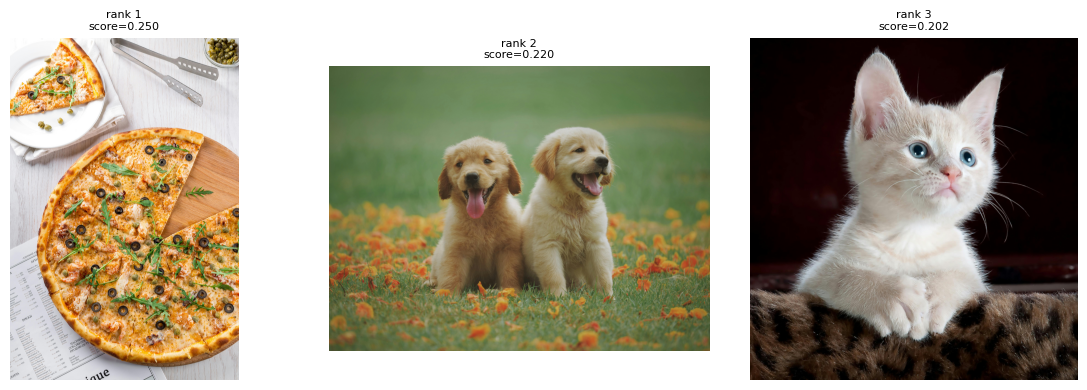

([2, 1, 0], [0.25021788477897644, 0.21971677243709564, 0.2016008198261261])

In [ ]:
search_images("tasty food with cheese", images, image_embeds, top_k=3)

# Text Classifier

In [ ]:
from torchvision.datasets import OxfordIIITPet

root = "./data"

train_dataset = OxfordIIITPet(
    root=root,
    split="trainval",
    target_types="category",
    download=True,
    transform=None,   # we want raw PIL images
)

test_dataset = OxfordIIITPet(
    root=root,
    split="test",
    target_types="category",
    download=True,
    transform=None,
)

class_names = train_dataset.classes
num_classes = len(train_dataset.classes)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Num classes:", num_classes)

100%|██████████| 792M/792M [00:34<00:00, 23.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.3MB/s]


Train size: 3680
Test size: 3669
Num classes: 37


In [ ]:
import random

def sample_dataset(dataset, max_samples=500):
    indices = list(range(len(dataset)))
    random.shuffle(indices)
    indices = indices[:max_samples]

    images = []
    labels = []
    for idx in indices:
        img, label = dataset[idx]  # img is PIL.Image, label is int
        images.append(img)
        labels.append(label)
    return images, labels

train_images, train_labels = sample_dataset(train_dataset, max_samples=500)
test_images, test_labels = sample_dataset(test_dataset, max_samples=200)

len(train_images), len(test_images)

(500, 200)

In [53]:
import torch
import numpy as np

def embed_images_in_batches(images, batch_size=64):
    """
    images: list[PIL.Image]
    returns: numpy array [N, D]
    """
    all_embeds = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        embeds = get_image_embeddings(batch)   # uses your function
        all_embeds.append(embeds.cpu())
    return torch.cat(all_embeds, dim=0)


In [54]:
train_embeddings = embed_images_in_batches(train_images, batch_size=64)
test_embeddings = embed_images_in_batches(test_images, batch_size=64)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

train_embeddings.shape, test_embeddings.shape

(torch.Size([500, 512]), torch.Size([200, 512]))

# k-NN

In [55]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# k-NN
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean", n_jobs=-1)
knn.fit(train_embeddings, train_labels)
knn_preds = knn.predict(test_embeddings)
print("k-NN accuracy:", accuracy_score(test_labels, knn_preds))
print(classification_report(test_labels, knn_preds, digits=3))

k-NN accuracy: 0.56
              precision    recall  f1-score   support

           0      0.444     0.800     0.571         5
           1      0.545     0.545     0.545        11
           2      0.600     0.500     0.545         6
           3      0.429     1.000     0.600         6
           4      0.000     0.000     0.000         3
           5      0.250     0.167     0.200         6
           6      0.667     0.667     0.667         6
           7      0.889     1.000     0.941         8
           8      0.286     1.000     0.444         2
           9      0.250     0.500     0.333         4
          10      0.429     1.000     0.600         3
          11      0.800     0.500     0.615         8
          12      0.556     0.833     0.667         6
          13      0.200     0.143     0.167         7
          14      0.667     0.500     0.571         4
          15      0.000     0.000     0.000         3
          16      0.375     0.750     0.500         4
       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Logistic Regression

In [56]:
# Logistic Regression
logreg = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
)
logreg.fit(train_embeddings, train_labels)
lr_preds = logreg.predict(test_embeddings)
print("LogReg accuracy:", accuracy_score(test_labels, lr_preds))
print(classification_report(test_labels, lr_preds, digits=3))

LogReg accuracy: 0.505
              precision    recall  f1-score   support

           0      1.000     0.200     0.333         5
           1      0.857     0.545     0.667        11
           2      0.556     0.833     0.667         6
           3      0.240     1.000     0.387         6
           4      0.000     0.000     0.000         3
           5      0.000     0.000     0.000         6
           6      0.000     0.000     0.000         6
           7      0.875     0.875     0.875         8
           8      0.500     0.500     0.500         2
           9      0.286     1.000     0.444         4
          10      0.750     1.000     0.857         3
          11      0.857     0.750     0.800         8
          12      0.667     0.667     0.667         6
          13      1.000     0.143     0.250         7
          14      1.000     0.750     0.857         4
          15      1.000     0.667     0.800         3
          16      0.500     0.250     0.333         4
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# XGBoost

In [65]:
X_train = train_embeddings.numpy()
X_test = test_embeddings.numpy()
y_train = train_labels
y_test = test_labels

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((500, 512), (200, 512), (500,), (200,))

In [66]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",    # good for CPU/Colab
    n_jobs=-1,
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_class=37, ...)

In [67]:
y_pred = xgb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"XGBoost on CLIP embeddings – accuracy: {acc:.4f}")
print()
print(classification_report(y_test, y_pred, digits=3))

XGBoost on CLIP embeddings – accuracy: 0.6450

              precision    recall  f1-score   support

           0      1.000     0.800     0.889         5
           1      0.714     0.455     0.556        11
           2      0.333     0.167     0.222         6
           3      0.400     0.667     0.500         6
           4      0.000     0.000     0.000         3
           5      0.333     0.167     0.222         6
           6      1.000     0.333     0.500         6
           7      0.667     1.000     0.800         8
           8      0.286     1.000     0.444         2
           9      0.800     1.000     0.889         4
          10      1.000     1.000     1.000         3
          11      0.500     0.375     0.429         8
          12      0.556     0.833     0.667         6
          13      0.714     0.714     0.714         7
          14      1.000     1.000     1.000         4
          15      0.500     0.333     0.400         3
          16      0.500     0.750 

# Zero-Shot

In [57]:
# Simple templates; you can add more for better accuracy
TEMPLATES = [
    "a photo of a {}",
    "a close-up photo of a {}",
    "a picture of a {}",
]

def build_zeroshot_classifier(class_names, templates):
    """
    class_names: list of strings (e.g. 'Abyssinian', 'american_bulldog')
    templates: list of strings with {}, e.g. "a photo of a {}"

    returns: torch.Tensor [num_classes, D] of class embeddings (CPU)
    """
    texts = []
    for name in class_names:
        pretty_name = name.replace("_", " ")
        for tmpl in templates:
            texts.append(tmpl.format(pretty_name))

    # Encode all texts at once
    text_embeds = get_text_embeddings(texts)   # [C * T, D] on device
    C = len(class_names)
    T = len(templates)
    text_embeds = text_embeds.view(C, T, -1)   # [C, T, D]

    # Average over templates
    class_embeds = text_embeds.mean(dim=1)     # [C, D]

    # L2-normalize again (since mean of unit vectors is not unit)
    class_embeds = class_embeds / class_embeds.norm(dim=-1, keepdim=True)

    return class_embeds.cpu()

In [58]:
class_embeds = build_zeroshot_classifier(class_names, TEMPLATES)
class_embeds.shape

torch.Size([37, 512])

In [59]:
# test_embeddings:   [N, D] on CPU
# class_embeds:      [C, D] on CPU

logits = cosine_similarity_matrix(test_embeddings, class_embeds)  # [N, C]
pred_labels = torch.argmax(logits, dim=1).numpy()                   # [N]

test_labels_np = test_labels  # already numpy array

accuracy = (pred_labels == test_labels_np).mean()
print(f"Zero-shot CLIP accuracy on sampled test set: {accuracy:.4f}")

Zero-shot CLIP accuracy on sampled test set: 0.8850


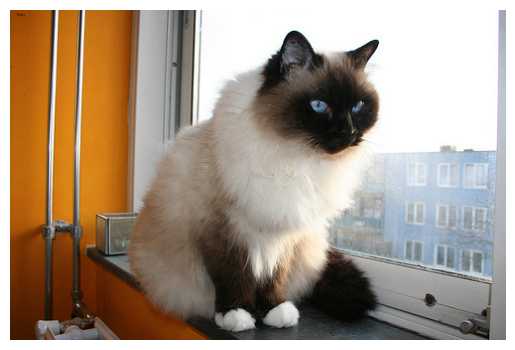

True: Birman
Pred: Birman


In [61]:
idx = 134
plt.imshow(test_images[idx])
plt.axis("off")
plt.show()

true_class = class_names[test_labels_np[idx]]
pred_class = class_names[pred_labels[idx]]
print("True:", true_class)
print("Pred:", pred_class)